# 01_train_transaction.ipynb

## End-to-End Machine Learning Pipeline for Online Fraud Detection

This notebook implements a complete end-to-end **Machine Learning** pipeline for fraud detection using `train_transaction.csv`.

**Objective:** predict the probability that an online transaction is fraudulent (`isFraud = 1`) or legitimate (`isFraud = 0`).


**Workflow:**
1. Environment setup
2. Full dataset loading from Google Drive
3. Exploratory Data Analysis (EDA)
4. Missing value analysis
5. Data cleaning and full usable feature preparation
6. Train-test split with stratification
7. Preprocessing pipeline
8. Scalable baseline model training
9. Hyperparameter tuning using Optuna
10. Experiment tracking using MLflow
11. Model evaluation
12. Conclusion

> This notebook is designed to use the full dataset while still being stable in Google Colab. For this reason, the classifier uses `SGDClassifier(loss="log_loss")`, which is a scalable logistic-regression-style model suitable for large datasets.

In [1]:
# ============================================================
# 1. Install required dependencies if missing
# ============================================================

import sys
import subprocess
import importlib.util


def install_if_missing(package_name, import_name=None):
    if import_name is None:
        import_name = package_name
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {package_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])
    else:
        print(f"{package_name} is already installed.")

install_if_missing("optuna")
install_if_missing("mlflow")

Installing optuna ...
Installing mlflow ...


In [2]:
# ============================================================
# 2. Import libraries
# ============================================================

import os
import gc
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

import optuna
import mlflow
import mlflow.sklearn

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Load the Full Dataset

The transaction dataset is loaded from Google Drive using:

```python
/content/drive/MyDrive/train_transaction.csv
```

This full-dataset version does **not** use `nrows`, so every row in `train_transaction.csv` will be loaded.

In [3]:
# ============================================================
# 3. Mount Google Drive and load the full dataset
# ============================================================

try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive mounted successfully.")
except Exception:
    print("Google Drive is already mounted or this is not a Colab environment.")

DATA_PATH = "/content/drive/MyDrive/train_transaction.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH}. Please make sure train_transaction.csv is located in MyDrive."
    )

# Full dataset loading: no nrows limitation is used here.
df = pd.read_csv(DATA_PATH)

print("Full dataset loaded successfully.")
print("Dataset shape:", df.shape)
display(df.head())

Mounted at /content/drive
Google Drive mounted successfully.
Full dataset loaded successfully.
Dataset shape: (590540, 394)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 4. Memory Optimization

The dataset is large. To reduce memory usage while keeping the full dataset, numeric columns are downcast where possible. This step does not remove rows; it only stores numeric values more efficiently.

In [4]:
# ============================================================
# 4. Memory optimization
# ============================================================

initial_memory = df.memory_usage(deep=True).sum() / 1024**2

for col in df.select_dtypes(include=["float64"]).columns:
    df[col] = pd.to_numeric(df[col], downcast="float")

for col in df.select_dtypes(include=["int64"]).columns:
    df[col] = pd.to_numeric(df[col], downcast="integer")

optimized_memory = df.memory_usage(deep=True).sum() / 1024**2
print(f"Initial memory usage: {initial_memory:.2f} MB")
print(f"Optimized memory usage: {optimized_memory:.2f} MB")

Initial memory usage: 2062.07 MB
Optimized memory usage: 1203.22 MB


## 5. Exploratory Data Analysis

This section checks the dataset structure, target distribution, and class imbalance. Fraud detection is usually highly imbalanced, so metrics such as PR-AUC and recall are more informative than accuracy alone.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: float32(376), int16(1), int32(2), int8(1), object(14)
memory usage: 916.3+ MB
None
Target distribution:


,count
isFraud,
0,569877
1,20663


Fraud rate: 3.4990%


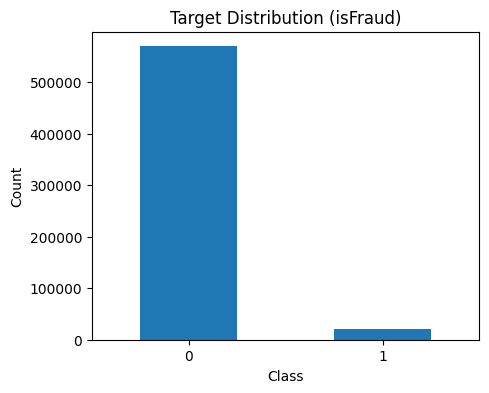

In [5]:
# ============================================================
# 5. Basic EDA
# ============================================================

print(df.info())

if "isFraud" not in df.columns:
    raise ValueError("Target column 'isFraud' not found.")

print("Target distribution:")
display(df["isFraud"].value_counts().to_frame("count"))

fraud_rate = df["isFraud"].mean()
print(f"Fraud rate: {fraud_rate:.4%}")

plt.figure(figsize=(5, 4))
df["isFraud"].value_counts().sort_index().plot(kind="bar")
plt.title("Target Distribution (isFraud)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [6]:
# ============================================================
# 6. Missing value summary
# ============================================================

missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_ratio": df.isna().mean()
}).sort_values("missing_ratio", ascending=False)

print("Top 20 columns with the highest missing value ratio:")
display(missing_summary.head(20))

Top 20 columns with the highest missing value ratio:


,missing_count,missing_ratio
dist2,552913,0.936284
D7,551623,0.934099
D13,528588,0.895093
D14,528353,0.894695
D12,525823,0.890410
D6,517353,0.876068
D9,515614,0.873123
D8,515614,0.873123
V153,508595,0.861237
V149,508595,0.861237


## 6. Data Cleaning and Full Usable Feature Preparation

This full-dataset version does not apply a fixed feature cap. Instead, it prepares all usable features after basic cleaning:

- `TransactionID` is removed because it is only an identifier.
- Columns with more than 90% missing values are removed because they contain too little usable information.
- All remaining numeric and categorical columns are included in the preprocessing pipeline.

This means the model uses the full dataset rows and all usable features after standard data cleaning.

In [7]:
# ============================================================
# 7. Cleaning and full usable feature preparation
# ============================================================

TARGET = "isFraud"
ID_COLS = [col for col in ["TransactionID"] if col in df.columns]

MISSING_THRESHOLD = 0.90
high_missing_cols = missing_summary[missing_summary["missing_ratio"] > MISSING_THRESHOLD].index.tolist()
high_missing_cols = [col for col in high_missing_cols if col != TARGET]

X = df.drop(columns=[TARGET] + ID_COLS + high_missing_cols, errors="ignore")
y = df[TARGET].astype(int)

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

# Remove constant columns because they do not help model learning.
constant_cols = []
for col in X.columns:
    if X[col].nunique(dropna=True) <= 1:
        constant_cols.append(col)

if len(constant_cols) > 0:
    X = X.drop(columns=constant_cols, errors="ignore")
    numeric_cols = [col for col in numeric_cols if col not in constant_cols]
    categorical_cols = [col for col in categorical_cols if col not in constant_cols]

print("Removed ID columns:", ID_COLS)
print("Removed high-missing columns:", len(high_missing_cols))
print("Removed constant columns:", len(constant_cols))
print("Numeric features used:", len(numeric_cols))
print("Categorical features used:", len(categorical_cols))
print("Total usable features used:", len(numeric_cols) + len(categorical_cols))

gc.collect()

Removed ID columns: ['TransactionID']
Removed high-missing columns: 2
Removed constant columns: 0
Numeric features used: 376
Categorical features used: 14
Total usable features used: 390


3280

## 7. Train-Test Split

The full dataset is split into training and testing sets using stratification. This preserves the original fraud class ratio in both subsets.

In [8]:
# ============================================================
# 8. Train-test split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Training target distribution:")
display(y_train.value_counts(normalize=True).to_frame("proportion"))
print("Testing target distribution:")
display(y_test.value_counts(normalize=True).to_frame("proportion"))

X_train shape: (472432, 390)
X_test shape: (118108, 390)
Training target distribution:


,proportion
isFraud,
0,0.965011
1,0.034989


Testing target distribution:


,proportion
isFraud,
0,0.965007
1,0.034993


## 8. Preprocessing Pipeline

The preprocessing pipeline handles numeric and categorical features separately:

- Numeric features: median imputation, float32 conversion, and standard scaling.
- Categorical features: most-frequent imputation and one-hot encoding.

The one-hot encoder uses version-safe initialization because different scikit-learn versions use different parameter names (`sparse_output` vs `sparse`).

In [9]:
# ============================================================
# 9. Preprocessing pipeline
# ============================================================

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("to_float32", FunctionTransformer(lambda x: x.astype(np.float32), validate=False)),
    ("scaler", StandardScaler(with_mean=False))
])

# Version-safe OneHotEncoder:
# Newer scikit-learn versions use sparse_output, older versions use sparse.
try:
    onehot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True,
        min_frequency=10
    )
except TypeError:
    onehot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=True
    )

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", onehot_encoder)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ],
    remainder="drop",
    sparse_threshold=0.3
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## 9. Baseline Model: Scalable Logistic Regression with SGDClassifier

Because the full dataset is large, this notebook uses `SGDClassifier(loss="log_loss")`. This model optimizes a logistic regression objective using stochastic gradient descent, making it more scalable for large datasets than standard batch Logistic Regression.

`class_weight="balanced"` is used to address class imbalance.

In [10]:
# ============================================================
# 10. Baseline scalable logistic model
# ============================================================

baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", SGDClassifier(
        loss="log_loss",
        penalty="l2",
        alpha=0.0001,
        max_iter=20,
        tol=1e-3,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)
baseline_proba = baseline_model.predict_proba(X_test)[:, 1]

baseline_metrics = {
    "accuracy": accuracy_score(y_test, baseline_pred),
    "precision": precision_score(y_test, baseline_pred, zero_division=0),
    "recall": recall_score(y_test, baseline_pred, zero_division=0),
    "f1": f1_score(y_test, baseline_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, baseline_proba),
    "pr_auc": average_precision_score(y_test, baseline_proba)
}

print("Baseline metrics:")
for metric_name, metric_value in baseline_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

print("Classification report:")
print(classification_report(y_test, baseline_pred, zero_division=0))

Baseline metrics:
accuracy: 0.8914
precision: 0.1843
recall: 0.6138
f1: 0.2835
roc_auc: 0.8243
pr_auc: 0.1566
Classification report:
              precision    recall  f1-score   support

           0       0.98      0.90      0.94    113975
           1       0.18      0.61      0.28      4133

    accuracy                           0.89    118108
   macro avg       0.58      0.76      0.61    118108
weighted avg       0.96      0.89      0.92    118108



## 10. Hyperparameter Tuning with Optuna

Optuna is used to tune the regularization strength (`alpha`) of the scalable logistic model. The objective metric is **PR-AUC**, which is appropriate for imbalanced fraud detection.

To keep the runtime reasonable while still using the full dataset for final training and testing, Optuna tuning is performed on a stratified subset of the training data. This is a common engineering strategy for large datasets. The final model is then trained on the full training set.

In [11]:
# ============================================================
# 11. Optuna hyperparameter tuning
# ============================================================

N_TRIALS = 8
TUNING_MAX_ROWS = 80_000

if len(X_train) > TUNING_MAX_ROWS:
    X_tune, _, y_tune, _ = train_test_split(
        X_train,
        y_train,
        train_size=TUNING_MAX_ROWS,
        random_state=RANDOM_STATE,
        stratify=y_train
    )
else:
    X_tune, y_tune = X_train, y_train

X_tune_train, X_tune_valid, y_tune_train, y_tune_valid = train_test_split(
    X_tune,
    y_tune,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_tune
)


def objective(trial):
    alpha = trial.suggest_float("alpha", 1e-6, 1e-2, log=True)
    penalty = trial.suggest_categorical("penalty", ["l2", "l1", "elasticnet"])

    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", SGDClassifier(
            loss="log_loss",
            penalty=penalty,
            alpha=alpha,
            max_iter=20,
            tol=1e-3,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])

    model.fit(X_tune_train, y_tune_train)
    valid_proba = model.predict_proba(X_tune_valid)[:, 1]
    return average_precision_score(y_tune_valid, valid_proba)

study = optuna.create_study(direction="maximize", study_name="full_train_transaction_sgd_tuning")
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

print("Best PR-AUC:", study.best_value)
print("Best parameters:", study.best_params)

[I 2026-05-15 11:57:40,139] A new study created in memory with name: full_train_transaction_sgd_tuning
[I 2026-05-15 11:57:48,805] Trial 0 finished with value: 0.16194474576275414 and parameters: {'alpha': 1.5969453928291527e-06, 'penalty': 'l1'}. Best is trial 0 with value: 0.16194474576275414.
[I 2026-05-15 11:57:56,834] Trial 1 finished with value: 0.15227249875610924 and parameters: {'alpha': 3.0793492589854573e-06, 'penalty': 'l2'}. Best is trial 0 with value: 0.16194474576275414.
[I 2026-05-15 11:58:03,412] Trial 2 finished with value: 0.1580086424625099 and parameters: {'alpha': 3.2454036552207373e-06, 'penalty': 'l2'}. Best is trial 0 with value: 0.16194474576275414.
[I 2026-05-15 11:58:13,478] Trial 3 finished with value: 0.11328197339597668 and parameters: {'alpha': 0.0012356923409836628, 'penalty': 'l1'}. Best is trial 0 with value: 0.16194474576275414.
[I 2026-05-15 11:58:26,380] Trial 4 finished with value: 0.15323762407312405 and parameters: {'alpha': 6.6896582711450845e-

Best PR-AUC: 0.2886883794067299
Best parameters: {'alpha': 0.0010071874492199567, 'penalty': 'l2'}


## 11. Final Model Training and MLflow Tracking

The final model is trained on the full training split using the best hyperparameters found by Optuna. MLflow is used to log parameters, metrics, and the trained model.

In [12]:
# ============================================================
# 12. Final model training with MLflow tracking
# ============================================================

mlflow.set_experiment("UTS_Full_Train_Transaction_Fraud_Classification")

best_params = study.best_params

final_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", SGDClassifier(
        loss="log_loss",
        penalty=best_params.get("penalty", "l2"),
        alpha=best_params.get("alpha", 0.0001),
        max_iter=30,
        tol=1e-3,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

with mlflow.start_run(run_name="full_dataset_sgd_logistic_optuna_final"):
    mlflow.log_param("dataset_path", DATA_PATH)
    mlflow.log_param("dataset_rows", len(df))
    mlflow.log_param("dataset_columns", df.shape[1])
    mlflow.log_param("missing_threshold", MISSING_THRESHOLD)
    mlflow.log_param("removed_high_missing_columns", len(high_missing_cols))
    mlflow.log_param("removed_constant_columns", len(constant_cols))
    mlflow.log_param("numeric_features_used", len(numeric_cols))
    mlflow.log_param("categorical_features_used", len(categorical_cols))
    mlflow.log_params(best_params)

    final_model.fit(X_train, y_train)

    y_pred = final_model.predict(X_test)
    y_proba = final_model.predict_proba(X_test)[:, 1]

    final_metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "pr_auc": average_precision_score(y_test, y_proba)
    }

    mlflow.log_metrics(final_metrics)
    mlflow.sklearn.log_model(final_model, "model")

print("Final metrics:")
for metric_name, metric_value in final_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

2026/05/15 11:59:31 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/15 11:59:32 INFO mlflow.store.db.utils: Updating database tables
2026/05/15 11:59:34 INFO mlflow.tracking.fluent: Experiment with name 'UTS_Full_Train_Transaction_Fraud_Classification' does not exist. Creating a new experiment.
2026/05/15 12:01:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/15 12:01:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Final metrics:
accuracy: 0.9557
precision: 0.3802
recall: 0.4205
f1: 0.3994
roc_auc: 0.8506
pr_auc: 0.3399


## 12. Model Evaluation

The final model is evaluated using metrics suitable for imbalanced fraud detection:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC
- Confusion matrix
- ROC curve
- Precision-recall curve

Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,111142,2833
Actual 1,2395,1738


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98    113975
           1       0.38      0.42      0.40      4133

    accuracy                           0.96    118108
   macro avg       0.68      0.70      0.69    118108
weighted avg       0.96      0.96      0.96    118108



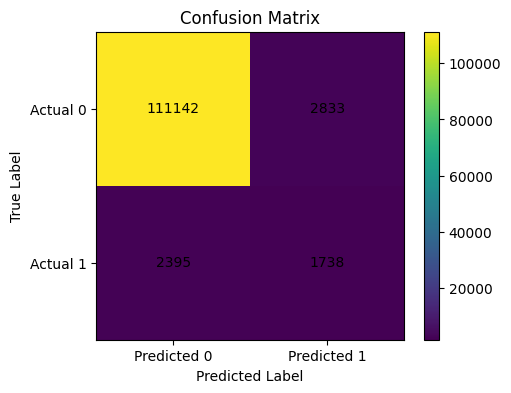

In [13]:
# ============================================================
# 13. Confusion matrix and classification report
# ============================================================

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=["Actual 0", "Actual 1"], columns=["Predicted 0", "Predicted 1"])

print("Confusion Matrix:")
display(cm_df)

print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["Predicted 0", "Predicted 1"])
plt.yticks([0, 1], ["Actual 0", "Actual 1"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.show()

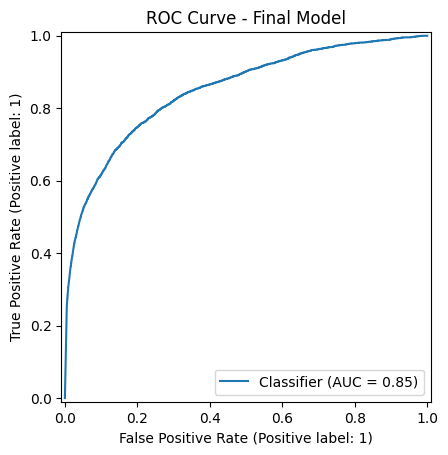

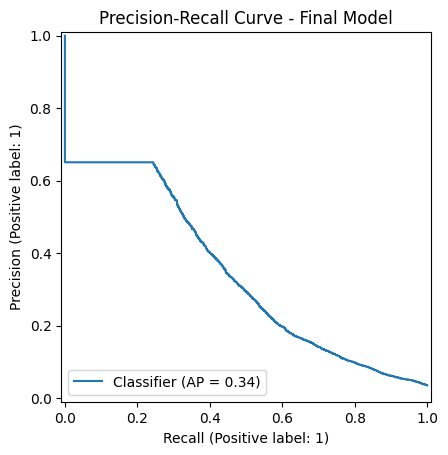

In [14]:
# ============================================================
# 14. ROC curve and Precision-Recall curve
# ============================================================

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve - Final Model")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title("Precision-Recall Curve - Final Model")
plt.show()

## 13. Baseline vs Final Model Comparison

This section compares the baseline model with the Optuna-tuned final model.

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Baseline SGD Logistic Model,0.891404,0.184281,0.613840,0.283464,0.824318,0.156635
1,Optuna Tuned SGD Logistic Model,0.955735,0.380223,0.420518,0.399357,0.850591,0.339943


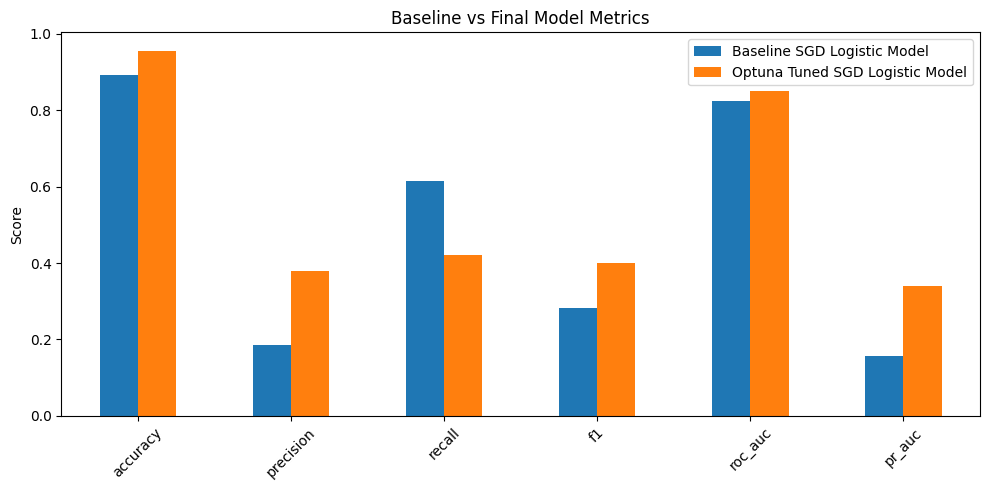

In [15]:
# ============================================================
# 15. Compare baseline and final model metrics
# ============================================================

comparison_df = pd.DataFrame([
    {"model": "Baseline SGD Logistic Model", **baseline_metrics},
    {"model": "Optuna Tuned SGD Logistic Model", **final_metrics}
])

display(comparison_df)

metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
comparison_df.set_index("model")[metric_cols].T.plot(kind="bar", figsize=(10, 5))
plt.title("Baseline vs Final Model Metrics")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

## 14. Save Output Artifacts

The metric comparison table is saved to Google Drive so it can be referenced in the GitHub repository README.

In [16]:
# ============================================================
# 16. Save output artifacts
# ============================================================

OUTPUT_DIR = "/content/drive/MyDrive/uts_train_transaction_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

comparison_path = os.path.join(OUTPUT_DIR, "full_train_transaction_model_comparison.csv")
comparison_df.to_csv(comparison_path, index=False)

print("Metric comparison saved to:", comparison_path)
print("MLflow runs are saved in the mlruns directory of the current runtime.")

Metric comparison saved to: /content/drive/MyDrive/uts_train_transaction_outputs/full_train_transaction_model_comparison.csv
MLflow runs are saved in the mlruns directory of the current runtime.


## 15. Conclusion

This notebook implements an end-to-end fraud detection pipeline using the full `train_transaction.csv` dataset. The full dataset is loaded without row sampling, and all usable features are prepared after standard data cleaning.

The workflow includes full dataset loading, memory optimization, EDA, missing value analysis, cleaning, preprocessing, baseline modeling, Optuna hyperparameter tuning, MLflow tracking, evaluation, and result comparison.

A scalable logistic-regression-style model (`SGDClassifier` with `loss="log_loss"`) is used because the full dataset is large. This model is appropriate for large-scale binary classification and helps reduce the risk of runtime or memory issues while still fulfilling the machine learning pipeline requirements.